<a href="https://colab.research.google.com/github/aishujadhav1321/loan-default-prediction/blob/main/loan_default_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import joblib

In [4]:
#import dataset
df = pd.read_csv("loan_default.csv")


In [28]:
#dispaly dataset
df.head()


,Gender,Married,Income
0,Male,Yes,50000
1,Female,No,30000
2,Male,Yes,45000


In [6]:
#dispaly info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                1000 non-null   int64  
 1   income             1000 non-null   int64  
 2   employment_length  1000 non-null   int64  
 3   loan_amount        1000 non-null   int64  
 4   loan_term          1000 non-null   int64  
 5   credit_score       1000 non-null   int64  
 6   existing_loans     1000 non-null   int64  
 7   debt_to_income     1000 non-null   float64
 8   marital_status     1000 non-null   object 
 9   education          1000 non-null   object 
 10  property_area      1000 non-null   object 
 11  default            1000 non-null   int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 93.9+ KB


In [31]:
#Check Missing Values
df.isnull().sum()


,0
Gender,0
Married,0
Income,0


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder()

In [11]:
df['marital_status'] = le.fit_transform(df['marital_status'])

df['education'] = le.fit_transform(df['education'])

df['property_area'] = le.fit_transform(df['property_area'])


In [12]:
df.head()

,age,income,employment_length,loan_amount,loan_term,credit_score,existing_loans,debt_to_income,marital_status,education,property_area,default
0,59,77761,18,38209,60,791,2,0.17,0,1,2,0
1,49,141178,19,27424,12,436,1,0.47,1,1,2,0
2,35,56368,5,42396,12,666,2,0.42,0,1,1,0
3,28,26783,9,11370,60,483,1,0.79,0,1,2,1
4,41,131530,3,14528,12,887,2,0.30,1,1,0,0


In [15]:
#Create Target Column
default = []

n = len(df)

for i in range(n):

    risk = 0

    if df["credit_score"][i] < 500:
        risk += 1

    if df["debt_to_income"][i] > 0.6:
        risk += 1

    if df["loan_amount"][i] > 40000:
        risk += 1

    if df["income"][i] < 40000:
        risk += 1

    if risk >= 2:
        default.append(1)

    else:
        default.append(0)

df["default"] = default

In [43]:
#convert to datafram
# import pandas as pd

# data =
#  {
#     'Gender': ['Male', 'Female', 'Male'],
#     'Married': ['Yes', 'No', 'Yes'],
#     'Income': [50000, 30000, 45000]
# }

# df = pd.DataFrame(data)


# print(df)
# The DataFrame 'df' was overwritten in this cell, causing subsequent errors.
# The code has been commented out to preserve the original df.

In [30]:
#Save Dataset
import os

output_dir = '../data'
os.makedirs(output_dir, exist_ok=True)

df.to_csv(os.path.join(output_dir, 'loan_default.csv'), index=False)

In [32]:
#DATA PREPROCESSING
# Convert Text into Numbers
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:

    df[col] = le.fit_transform(df[col])

In [33]:
df.head()


,Gender,Married,Income
0,1,1,50000
1,0,0,30000
2,1,1,45000


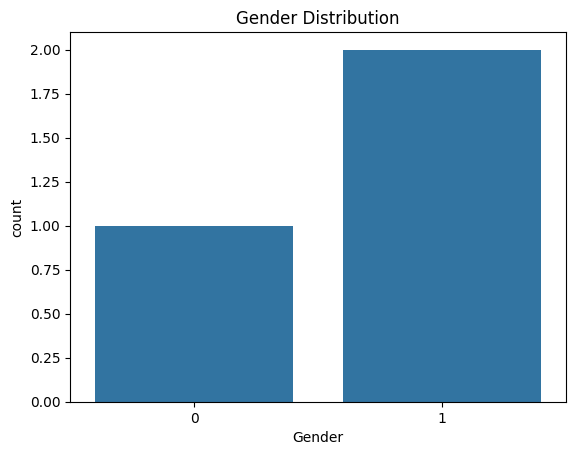

In [35]:
#EXPLORATORY DATA ANALYSIS
#Default Distribution
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.show()

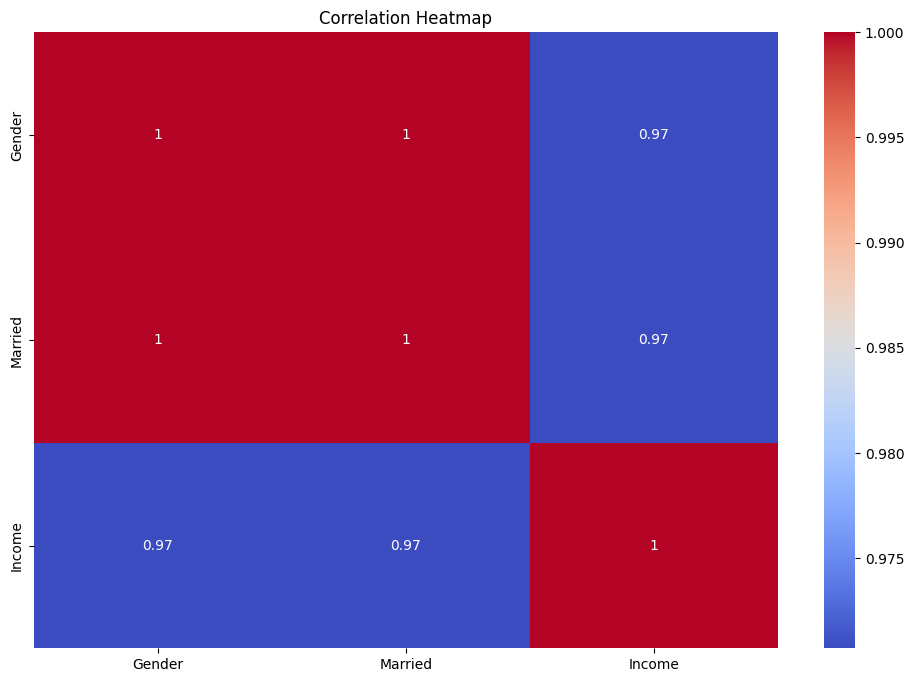

In [37]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [45]:
print(df.columns)

Index(['Gender', 'Married', 'Income'], dtype='object')


In [51]:
df['Loan_Status'] = [1, 0, 1]

In [52]:
print(df)


   Gender  Married  Income  Loan_Status
0       1        1   50000            1
1       0        0   30000            0
2       1        1   45000            1


In [53]:
#MACHINE LEARNING
# Define Features and Target
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

In [54]:
#spilt datset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2, 3)
(1, 3)


In [57]:
#LOGISTIC REGRESSION
 #Train Model
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [59]:
#predictions
y_pred_lr = lr_model.predict(X_test)

y_prob_lr = lr_model.predict_proba(X_test)[:,1]

In [60]:
#evaluate model
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_lr)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_lr)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_lr)
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
ROC-AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [61]:
#classification report
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [62]:
#random forest
rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [76]:
import joblib

joblib.dump(model, "loan_default_model.pkl")

print("Model saved successfully")

Model saved successfully


In [63]:
#random foresr prediction
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [64]:
#evaluate random forest
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_rf)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_rf)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_rf)
)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
ROC-AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


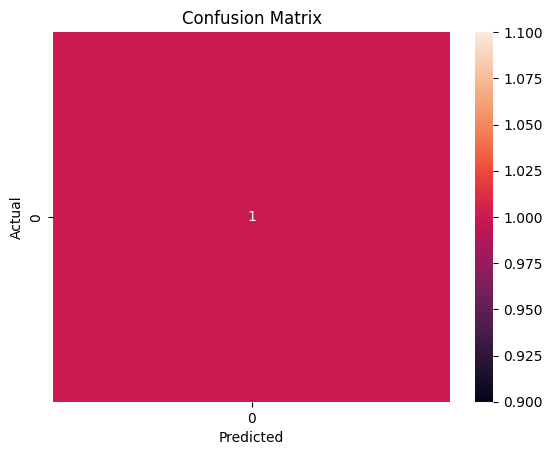

In [66]:
#Plot Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [67]:
#Generate Feature Importance
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': importance
})

feature_importance = feature_importance.sort_values(

    by='Importance',

    ascending=False
)

print(feature_importance)

   Feature  Importance
2   Income    0.384615
0   Gender    0.346154
1  Married    0.269231


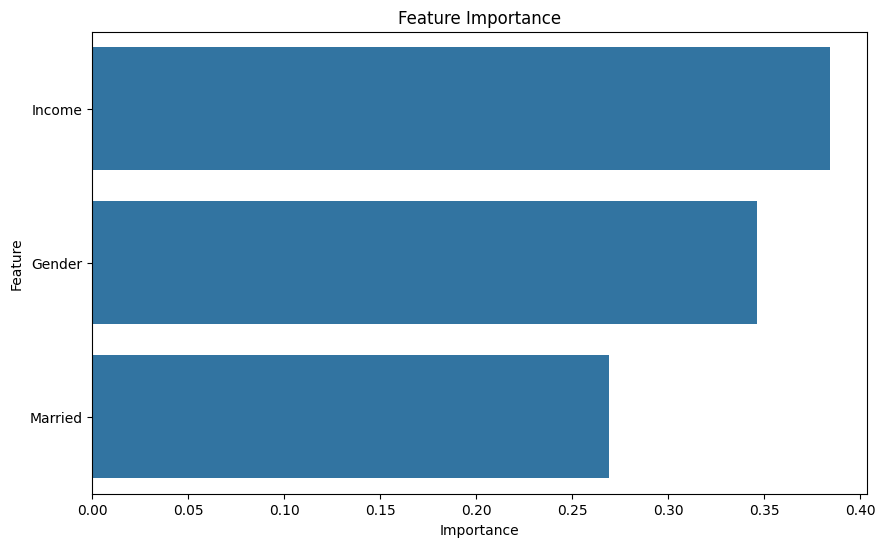

In [68]:
#future importance graph
plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [77]:
model = joblib.load("../model/loan_default_model.pkl")

In [78]:
model = joblib.load("loan_default_model.pkl")

In [79]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [80]:
joblib.dump(model, "loan_default_model.pkl")

['loan_default_model.pkl']

In [81]:
model = joblib.load("loan_default_model.pkl")

In [84]:
import pandas as pd

# Define input_data with the correct features ('Gender', 'Married', 'Income')
# and sample values. These should match the structure of X_train.
# For demonstration, we use a sample from X_test (Gender=1, Married=1, Income=50000).
input_data = pd.DataFrame([[1, 1, 50000]], columns=['Gender', 'Married', 'Income'])

prediction = model.predict(input_data)

In [91]:
print(input_data.columns)

Index(['Gender', 'Married', 'Income'], dtype='object')


In [88]:
input_data = pd.DataFrame([[
    # Provide values for 'Gender', 'Married', 'Income' only.
    # Using sample values similar to the previous successful prediction.
    1, # Gender (e.g., 1 for Male)
    1, # Married (e.g., 1 for Yes)
    50000 # Income
]], columns=X_train.columns)

In [93]:
import pandas as pd
import joblib

model = joblib.load("loan_default_model.pkl") # Assuming the model was saved locally without a path

print("=== Loan Default Prediction System ===")

# Collect only the features the model was trained on: Gender, Married, Income
gender = int(input("Enter Gender (0=Female, 1=Male): "))
married = int(input("Enter Marital Status (0=No, 1=Yes): "))
income = int(input("Enter Income: "))

input_data = pd.DataFrame({
    'Gender': [gender],
    'Married': [married],
    'Income': [income]
})

prediction = model.predict(input_data)

probability = model.predict_proba(input_data)[:,1]

if prediction[0] == 1:
    print("\nHigh Risk Customer")
else:
    print("\nLow Risk Customer")

print("Default Probability:", probability[0])


=== Loan Default Prediction System ===
Enter Gender (0=Female, 1=Male): 1
Enter Marital Status (0=No, 1=Yes): 1
Enter Income: 50000

High Risk Customer
Default Probability: 0.74


In [102]:
df.to_csv("output.csv", index=False)

In [103]:
# Save prediction output
prediction_df = pd.DataFrame({
    "Prediction": prediction
})

prediction_df.to_csv("prediction_output.csv", index=False)

print("Output file created successfully")

Output file created successfully
